In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load ---
path = "data_transportation_faculty.xlsx"
people = pd.read_excel(path, sheet_name="People")

In [2]:
import pandas as pd
import numpy as np

# Start by copying the original column
people['Origin_Group'] = people['UG_Country']

# Countries kept as their own group (>=10 rule)
keep_as_is = [
    'USA',
    'China',
    'India',
    'Iran',
    'Egypt',
    'South Korea',
    'Bangladesh',
    'Greece',
    'Turkey',
    'Canada'
]

# Europe (other)
europe_other = [
    'England', 'France', 'Italy', 'Poland', 'Spain', 'Serbia',
    'Switzerland', 'Sweden', 'Finland', 'Denmark'
]

# Latin / South America
latin_south_america = [
    'Argentina', 'Brazil', 'Chile', 'Colombia', 'Peru',
    'Uruguay', 'Venezuela', 'Dominican Republic'
]

# Africa (excluding Egypt, which is its own group)
africa = [
    'Ghana', 'Nigeria', 'Sudan', 'Tanzania'
]

# Apply regional groupings
people.loc[people['UG_Country'].isin(europe_other), 'Origin_Group'] = 'Europe (other)'
people.loc[people['UG_Country'].isin(latin_south_america), 'Origin_Group'] = 'Latin / South America'
people.loc[people['UG_Country'].isin(africa), 'Origin_Group'] = 'Africa'

# Everything else that is not in keep_as_is and not missing -> Other origins
mask_other = (
    ~people['UG_Country'].isin(keep_as_is)
    & ~people['UG_Country'].isin(europe_other)
    & ~people['UG_Country'].isin(latin_south_america)
    & ~people['UG_Country'].isin(africa)
    & people['UG_Country'].notna()
)

people.loc[mask_other, 'Origin_Group'] = 'Other origins'

# Explicitly label missing
people.loc[people['UG_Country'].isna(), 'Origin_Group'] = 'Missing / Unknown'


In [3]:
people['UG_Country'].isna().sum()

36

In [4]:
people['Origin_Group'].value_counts(dropna=False)

USA                      180
China                    112
Missing / Unknown         36
Other origins             31
India                     31
Iran                      29
Europe (other)            23
Latin / South America     17
Egypt                     17
South Korea               15
Greece                    14
Turkey                    14
Bangladesh                14
Africa                    12
Canada                     8
Name: Origin_Group, dtype: int64

# Secion 4 

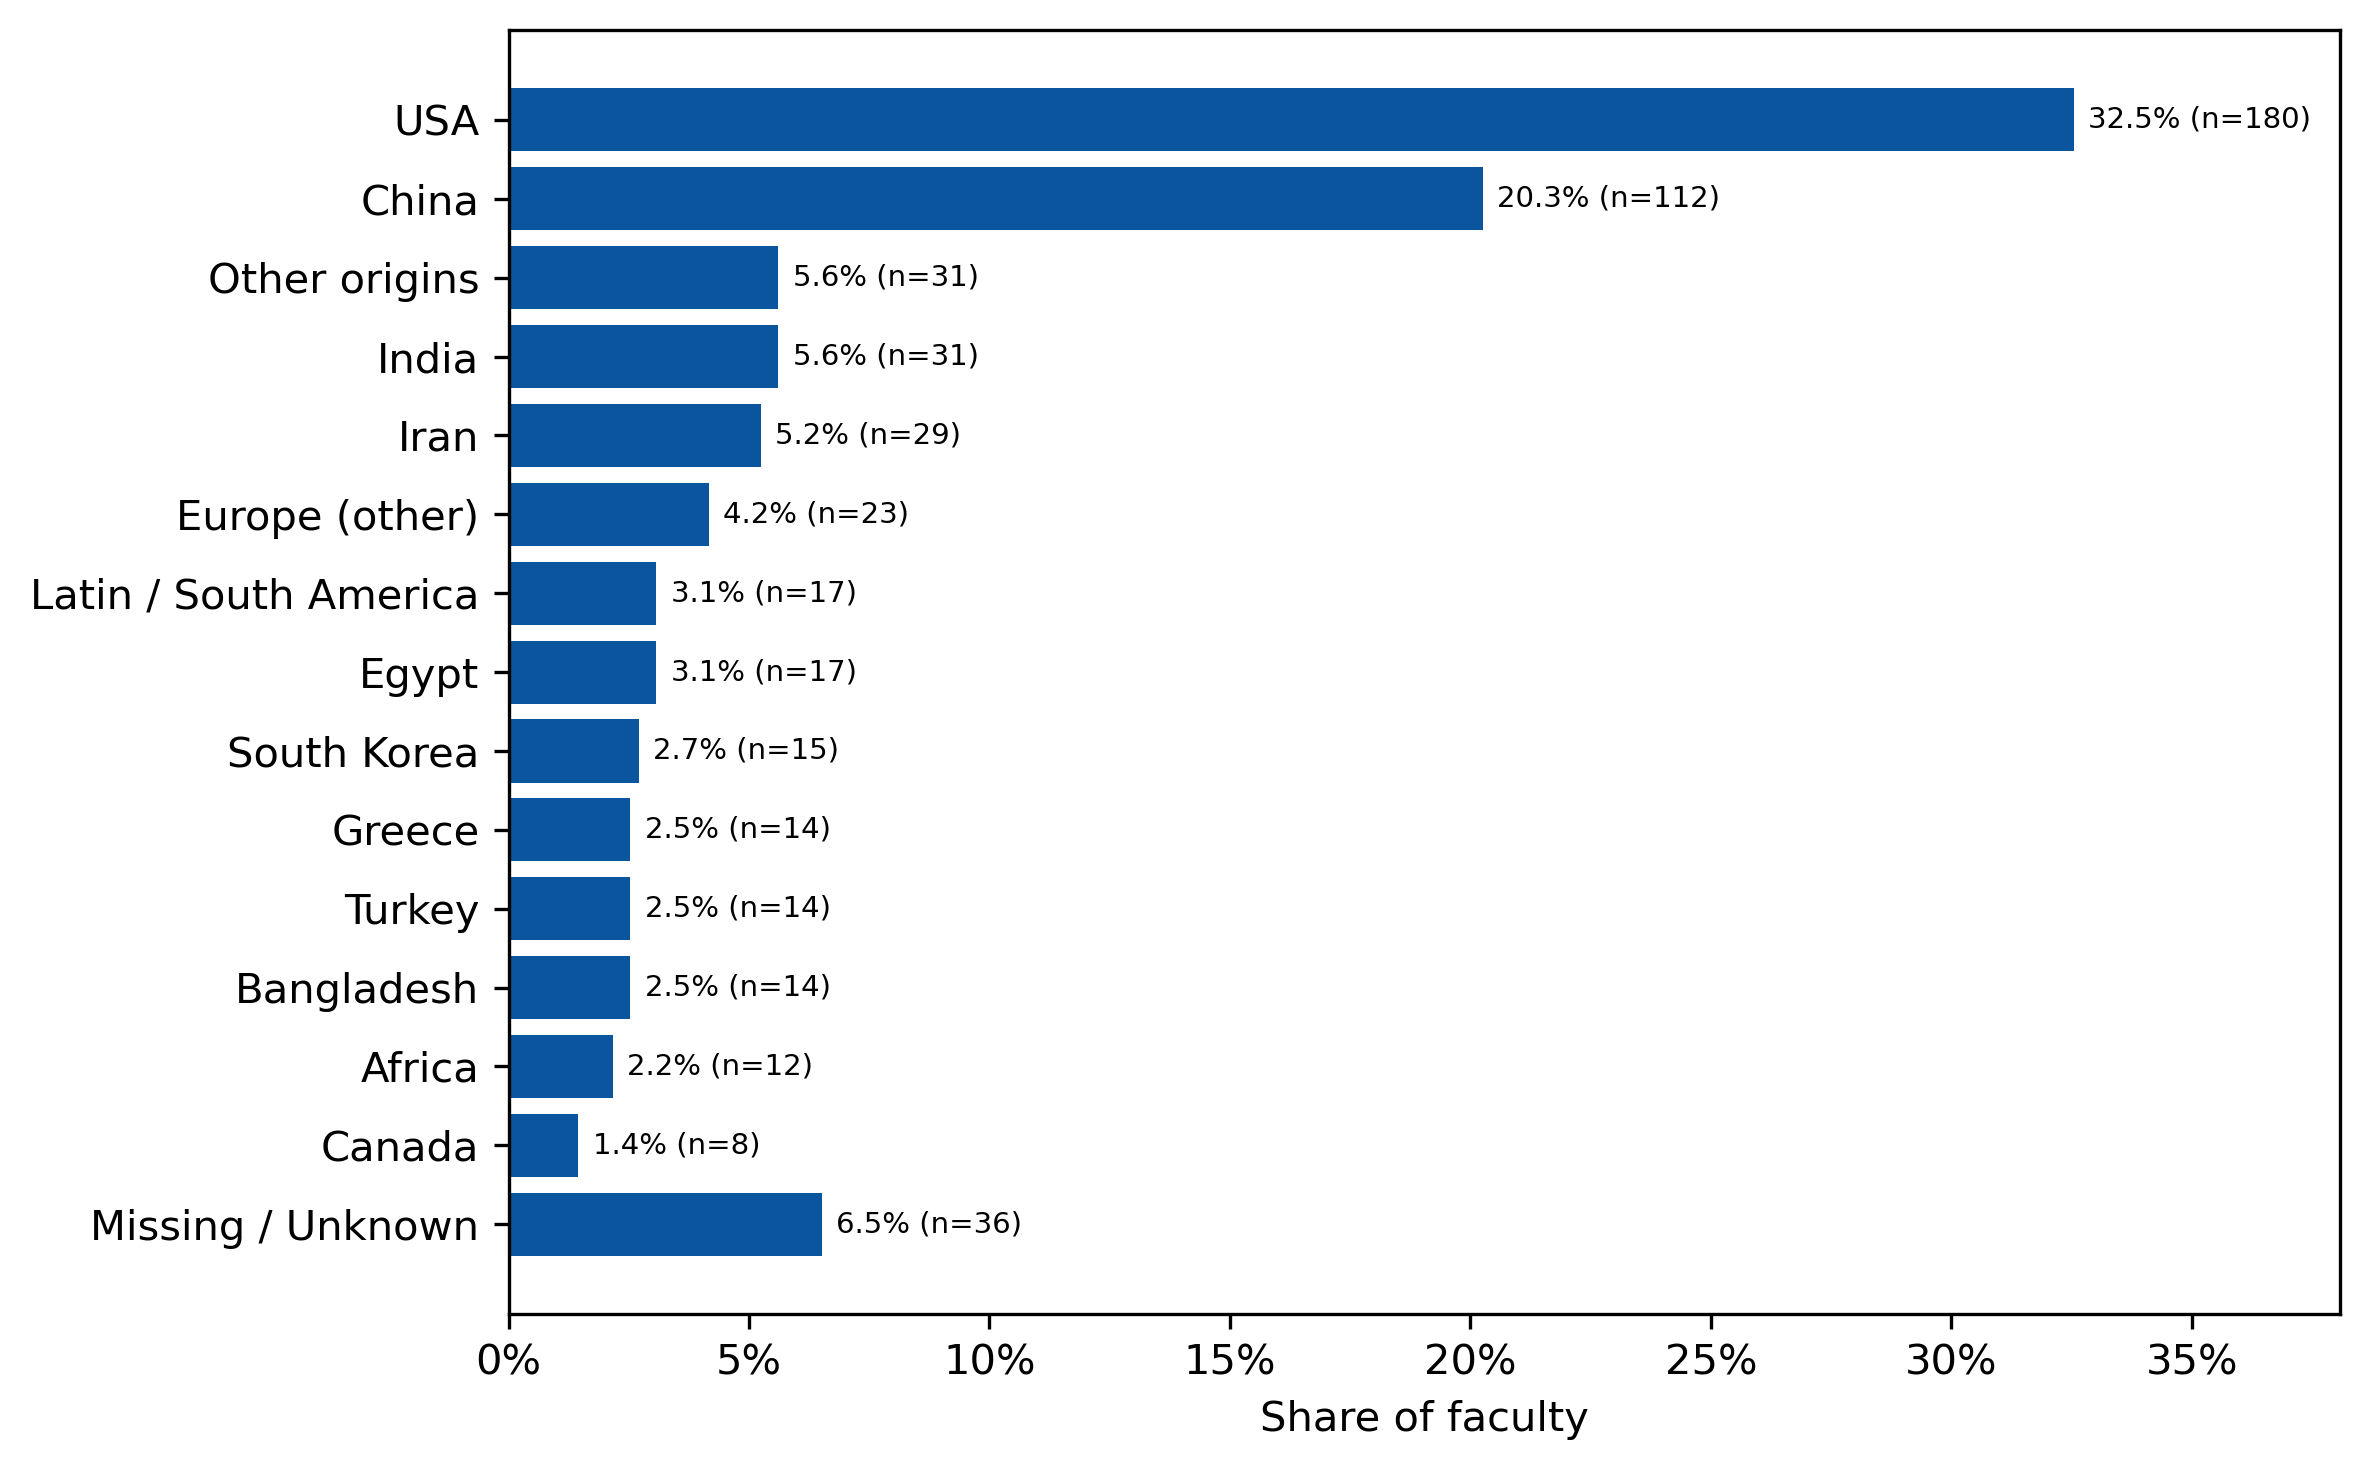

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

df = people.copy()

counts = df["Origin_Group"].value_counts()
shares = counts / counts.sum()

label_to_push = "Missing / Unknown"

# Sort descending for readability
order = shares.sort_values(ascending=False).index.tolist()

# Remove missing then append it at the end of the list
if label_to_push in order:
    order = [x for x in order if x != label_to_push] + [label_to_push]

counts = counts.loc[order]
shares = shares.loc[order]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.set_facecolor("white")

ax.barh(shares.index.astype(str), shares.values, color="#0b559f")

# Make the first item appear at the top (so descending looks natural)
ax.invert_yaxis()

# ax.set_title("Aggregate faculty capacity by underg country")
ax.set_xlabel("Share of faculty")

xticks = np.arange(0, 0.36, 0.05)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x*100)}%" for x in xticks])

ax.set_xlim(0, shares.max() * 1.17)

for y, country in enumerate(shares.index):
    n = int(counts.loc[country])
    ax.text(shares.loc[country] + 0.003, y,
            f"{shares.loc[country]*100:.1f}% (n={n})",
            va="center", fontsize=7)

fig.tight_layout()
fig.savefig(
    "fig_origin_composition.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white",
    transparent=False,
)
plt.show()


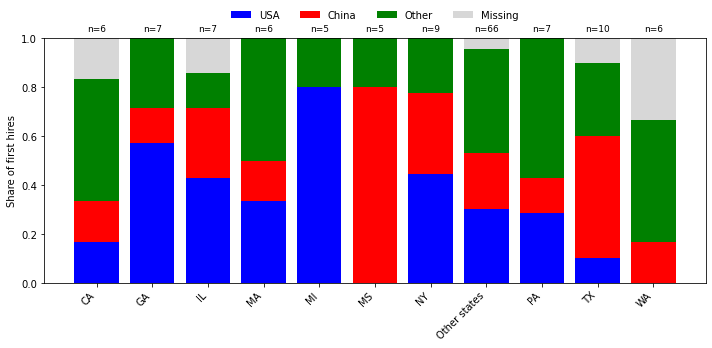

Saved figure to fig_first_hire_state_by_origin.png


In [6]:
# ============================================================
# Geography-first analysis using FIRST HIRE SCHOOL → STATE
# Produces: state-level stacked bar plot by origin
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. USER SETTINGS (EDIT IF NEEDED)
# ============================================================

# Main dataframe already loaded in memory
# df = your main people dataframe

FIRST_HIRE_SCHOOL_COL = "First_Hire"   # column in df
ORIGIN_COL = "UG_Country"                     # or "PhD_Country"

CROSSWALK_PATH = "first_hire_school_to_state.csv"
OUTPUT_FIG = "fig_first_hire_state_by_origin.png"

TOP_N_STATES = 10  # number of states shown explicitly

# ============================================================
# 1. LOAD + CLEAN DATA
# ============================================================

d = people.copy()

# Normalize school names
d[FIRST_HIRE_SCHOOL_COL] = (
    d[FIRST_HIRE_SCHOOL_COL]
    .astype(str)
    .str.strip()
)

# Load crosswalk
cw = pd.read_csv(CROSSWALK_PATH)

cw["First_Hire_School"] = (
    cw["First_Hire_School"]
    .astype(str)
    .str.strip()
)

cw["State"] = (
    cw["State"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"": np.nan, "NAN": np.nan})
)

# Merge state into main dataframe
d = d.merge(
    cw,
    how="left",
    left_on=FIRST_HIRE_SCHOOL_COL,
    right_on="First_Hire_School"
)

# Drop cases with no usable state
d = d.dropna(subset=["State"])

# ============================================================
# 2. ORIGIN GROUPING
# ============================================================

def map_origin(x):
    if pd.isna(x) or str(x).strip() == "":
        return "Missing"
    x = str(x).strip()
    if x in ["USA", "United States"]:
        return "USA"
    if x == "China":
        return "China"
    return "Other"

d["origin_group"] = d[ORIGIN_COL].apply(map_origin)

# ============================================================
# 3. TOP STATES IDENTIFICATION
# ============================================================

top_states = (
    d["State"]
    .value_counts()
    .head(TOP_N_STATES)
    .index
)

d["state_group"] = d["State"].where(
    d["State"].isin(top_states),
    "Other states"
)

# ============================================================
# 4. COUNTS AND SHARES
# ============================================================

counts = (
    d
    .groupby(["state_group", "origin_group"])
    .size()
    .unstack(fill_value=0)
)

origin_order = ["USA", "China", "Other", "Missing"]
for col in origin_order:
    if col not in counts.columns:
        counts[col] = 0

counts = counts[origin_order]

shares = counts.div(counts.sum(axis=1), axis=0)

# ============================================================
# 5. PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(shares))
x = np.arange(len(shares))

color_map = {
    "USA": 'blue',        # your existing color
    "China": 'red',    # your existing color
    "Other": 'green',    # your existing color
    "Missing": "#BDBDBD"
}

alpha_map = {
    "Missing": 0.6
}

for col in origin_order:
    ax.bar(
        x,
        shares[col],
        bottom=bottom,
        label=col,
        color=color_map[col],
        alpha=alpha_map.get(col, 1.0)
    )
    bottom += shares[col].values


ax.set_xticks(x)
ax.set_xticklabels(shares.index, rotation=45, ha="right")
ax.set_ylim(0, 1)

ax.set_ylabel("Share of first hires")
# ax.set_title("First U.S. faculty appointments by state and origin")

# Annotate sample sizes
state_n = counts.sum(axis=1).values
for i, n in enumerate(state_n):
    ax.text(i, 1.02, f"n={n}", ha="center", va="bottom", fontsize=9)

ax.legend(
    frameon=False,
    ncol=4,
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center"
)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=300, bbox_inches="tight")
plt.savefig(
    OUTPUT_FIG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white",
    transparent=False,
)
plt.show()

print(f"Saved figure to {OUTPUT_FIG}")

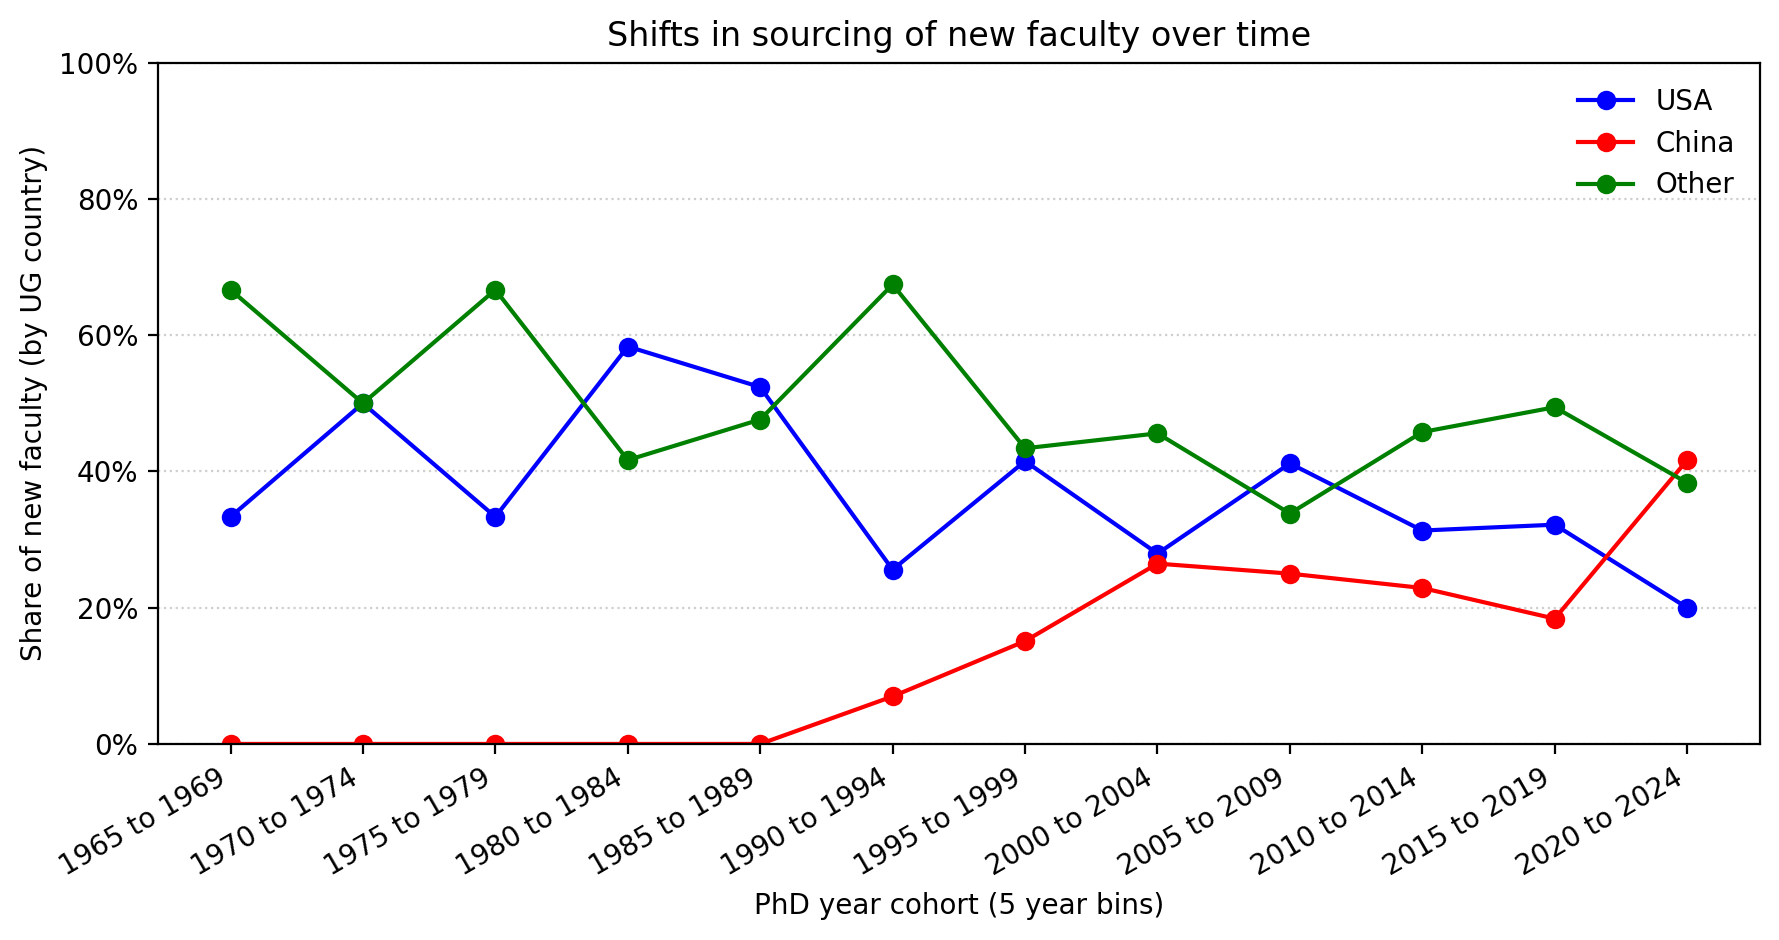

PhD_Year_Bin_Label
1965 to 1969     3
1970 to 1974     6
1975 to 1979     9
1980 to 1984    12
1985 to 1989    21
1990 to 1994    43
1995 to 1999    53
2000 to 2004    68
2005 to 2009    68
2010 to 2014    83
2015 to 2019    87
2020 to 2024    60
dtype: int64


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

df = people.copy()

# ---- 1) Clean PhD year ----
df["PhD_Year"] = pd.to_numeric(df["PhD_Year"], errors="coerce")
df = df.dropna(subset=["PhD_Year"])
df["PhD_Year"] = df["PhD_Year"].astype(int)

# ---- 2) Map UG country to USA / China / Other ----
def to_3group_ug(x):
    if x == "USA":
        return "USA"
    elif x == "China":
        return "China"
    else:
        return "Other"

df["UG_Origin_3"] = df["UG_Country"].astype(str).apply(to_3group_ug)

# ---- 3) Build 5 year PhD cohorts ----
bin_start = int(np.floor(df["PhD_Year"].min() / 5) * 5)
# bin_end = int(np.ceil((df["PhD_Year"].max() + 1) / 5) * 5)
bin_start = 1965
bin_end = 2026

bins = list(range(bin_start, bin_end + 1, 5))

df["PhD_Year_Bin"] = pd.cut(df["PhD_Year"], bins=bins, right=False)

bin_labels = {
    b: f"{b.left} to {b.right - 1}"
    for b in df["PhD_Year_Bin"].cat.categories
}

df["PhD_Year_Bin_Label"] = df["PhD_Year_Bin"].map(bin_labels)

# ---- 4) Cohort shares by UG origin ----
tab = (
    df.groupby(["PhD_Year_Bin_Label", "UG_Origin_3"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["USA", "China", "Other"], fill_value=0)
)

shares = tab.div(tab.sum(axis=1), axis=0)
cohort_n = tab.sum(axis=1)

# ---- 5) Plot ----
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=200, facecolor="white")
ax.set_facecolor("white")

x = np.arange(len(shares.index))

ax.plot(x, shares["USA"], marker="o", label="USA", color = 'blue')
ax.plot(x, shares["China"], marker="o", label="China", color = 'red')
ax.plot(x, shares["Other"], marker="o", label="Other", color = 'green')

ax.set_xticks(x)
ax.set_xticklabels(shares.index, rotation=30, ha="right")

ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(t*100)}%" for t in ax.get_yticks()])

ax.set_xlabel("PhD year cohort (5 year bins)")
ax.set_ylabel("Share of new faculty (by UG country)")
ax.set_title("Shifts in sourcing of new faculty over time")

ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    "fig_entry_trends_ugcountry_phdyear_bins.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white",
    transparent=False
)

plt.show()

# Optional: cohort sizes for caption / appendix
print(cohort_n)


In [8]:
people['UG_Country'].value_counts()

USA                     180
China                   112
India                    31
Iran                     29
Egypt                    17
South Korea              15
Bangladesh               14
Greece                   14
Turkey                   14
Canada                    8
Colombia                  8
Serbia                    5
Taiwan                    5
Jordan                    5
Lebanon                   5
Ghana                     4
Tanzania                  4
Italy                     3
Pakistan                  3
England                   3
France                    3
Sri Lanka                 3
Poland                    3
Chile                     2
Russia                    2
Nigeria                   2
Sudan                     2
Argentina                 2
Israel                    2
Spain                     2
Singapore                 1
Brazil                    1
Haiti                     1
Iraq                      1
Sweden                    1
Finland             

In [9]:
N = len(people)
missing_ug = people['UG_Country'].isna().sum()
nonmissing_ug = N - missing_ug
print(N, missing_ug, nonmissing_ug)  # expect 553, 36, 517

# What does your appendix table column actually use
for col in ['UG_Country', 'PhD_Country', 'Origin_Country', 'UG_Country_filled', 'UG_Country_Final']:
    if col in people.columns:
        print(col, people[col].isna().sum(), len(people) - people[col].isna().sum())

# # If you built table_counts from some df, check its length and missingness too
# print(len(df_for_table), df_for_table['UG_Country'].isna().sum())


553 36 517
UG_Country 36 517
PhD_Country 7 546


In [10]:
# ============================================================
# STATE-LEVEL FIRST HIRE COUNTS BY ORIGIN (APPENDIX TABLE)
# ============================================================

import pandas as pd

# Assumes you already ran the merge and have:
# d["State"] and d["origin_group"]

# ----------------------------
# Build counts
# ----------------------------
state_counts = (
    d
    .groupby(["State", "origin_group"])
    .size()
    .unstack(fill_value=0)
)

# Ensure consistent column order
origin_order = ["USA", "China", "Other", "Missing"]
for col in origin_order:
    if col not in state_counts.columns:
        state_counts[col] = 0

state_counts = state_counts[origin_order]

# Add total column
state_counts["Total"] = state_counts.sum(axis=1)

# Sort by total descending
state_counts = state_counts.sort_values("Total", ascending=False)

# Reset index for LaTeX export
state_counts = state_counts.reset_index()

# ----------------------------
# Export to LaTeX
# ----------------------------
latex_table = state_counts.to_latex(
    index=False,
    caption="State-level counts of first U.S. faculty appointments by origin group",
    label="tab:state_first_hire_counts",
    column_format="lrrrrr",
    longtable=False,
    escape=False
)

print(latex_table)

# Optional: save to file
with open("table_state_first_hire_counts.tex", "w") as f:
    f.write(latex_table)

print("Saved LaTeX table to table_state_first_hire_counts.tex")


\begin{table}
\centering
\caption{State-level counts of first U.S. faculty appointments by origin group}
\label{tab:state_first_hire_counts}
\begin{tabular}{lrrrrr}
\toprule
State &  USA &  China &  Other &  Missing &  Total \\
\midrule
   TX &    1 &      5 &      3 &        1 &     10 \\
   NY &    4 &      3 &      2 &        0 &      9 \\
   IL &    3 &      2 &      1 &        1 &      7 \\
   PA &    2 &      1 &      4 &        0 &      7 \\
   GA &    4 &      1 &      2 &        0 &      7 \\
   WA &    0 &      1 &      3 &        2 &      6 \\
   CA &    1 &      1 &      3 &        1 &      6 \\
   MA &    2 &      1 &      3 &        0 &      6 \\
   MI &    4 &      0 &      1 &        0 &      5 \\
   MS &    0 &      4 &      1 &        0 &      5 \\
   MO &    1 &      2 &      1 &        0 &      4 \\
   OH &    1 &      1 &      1 &        1 &      4 \\
   NJ &    2 &      0 &      1 &        1 &      4 \\
   FL &    0 &      2 &      2 &        0 &      4 \\
   UT &

C:\Users\appuals\AppData\Local\Temp\ipykernel_11180\2411491018.py:40: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = state_counts.to_latex(
